# Building a Correspondence Network from the BERTopic Labels

The previous notebook (`wolff_llm_labels.ipynb`) ended with `hsa_sample_mpnet_labels.csv`, one row per letter, carrying the sender, the receiver, the language, and the topic BERTopic assigned to it. That table already holds a network, it just isn't shaped like one yet: every letter is a connection between two people, and every topic is something several people wrote about. This notebook turns those connections into an actual graph with `networkx`, a Python library for building and manipulating graphs, and exports it as GraphML, a file format that Gephi Lite (a browser-based tool for exploring and clustering networks visually) can open directly.

In [3]:
import networkx as nx
import pandas as pd


We reuse the labeled dataframe the previous notebook produced. Only a few of its columns matter for a network: `sender` and `receiver` become the people the graph connects, `language` and `topic_id` describe what a given letter was about, and `gemma_label` gives that topic a readable name instead of just a number.

In [5]:
df = pd.read_csv("sample_data/hsa_sample_mpnet_labels.csv")

A quick look at the data before building anything: `df.info()` confirms the columns and row count came through as expected, and checking for missing `gemma_label` values matters specifically here, since a `NaN` attribute would get written into the graph as an empty or malformed value instead of failing loudly.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   source_file              1998 non-null   str    
 1   pid                      1998 non-null   str    
 2   sender_id                1998 non-null   str    
 3   sender                   1998 non-null   str    
 4   receiver_id              1998 non-null   str    
 5   receiver                 1998 non-null   str    
 6   date                     1977 non-null   str    
 7   text                     1998 non-null   str    
 8   language                 1998 non-null   str    
 9   keywords                 1998 non-null   str    
 10  word_count               1998 non-null   int64  
 11  Document                 1998 non-null   str    
 12  topic_id                 1998 non-null   int64  
 13  Name                     1998 non-null   str    
 14  Representation           1998 non-n

In [7]:
df[df["gemma_label"].isna() == True]

,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,...,Document,topic_id,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,gemma_label,ollama_label


In [8]:
df.head()

,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,...,Document,topic_id,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,gemma_label,ollama_label
0,hsa.letter.9937.xml,L.9937-6,https://gams.uni-graz.at/o:hsa.persons#P.1560,Geibel (jr.),https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1879-10-10,Sie müßten das leicht von jedem älteren Colleg...,de,Universität Graz,...,Sie müßten das leicht von jedem älteren Colleg...,6,6_journal_revista_envío_jornal,"['journal', 'revista', 'envío', 'jornal', 'hef...",['J’ai reçu hier votre estimée du 5 courant et...,journal - revista - envío - jornal - heft - co...,0.695812,False,Journal publishing / Periodicals,Old Letter Exchange\n\nThis label captures the...
1,hsa.letter.2512.xml,L.2512-2,https://gams.uni-graz.at/o:hsa.persons#P.1451,Erber,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1883-01-20,"Ich bin auch bereit, allen Ihren gütigsten Auf...",de,Sprachkontaktphänomene; Soziolinguistik; Sprac...,...,"Ich bin auch bereit, allen Ihren gütigsten Auf...",0,0_letter_carta_ex_sempre,"['letter', 'carta', 'ex', 'sempre', 'didl', 'r...",['Nous allons bientôt inviter nos collègues de...,letter - carta - ex - sempre - didl - reçu - r...,1.000000,False,Correspondence,Diplomatic Correspondence and Academic Affairs
2,hsa.letter.4162.xml,L.4162-2,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,https://gams.uni-graz.at/o:hsa.persons#P.2017,Leite de Vasconcelos,1901-05-23,"S. M. der König Carlos hat, so viel ich weiss,...",de,Fischereigeräte; Literaturbeschaffung; Revista...,...,"S. M. der König Carlos hat, so viel ich weiss,...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture
3,hsa.letter.3315.xml,L.3315-3,https://gams.uni-graz.at/o:hsa.persons#P.2741,Sket,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1877-11-07,Wenn es mir gelingt im Februar die Prüfung zu ...,de,Biographisches; Dialekte; Diezstiftung; Lautph...,...,Wenn es mir gelingt im Februar die Prüfung zu ...,-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture
4,hsa.letter.8585.xml,L.8585-5,https://gams.uni-graz.at/o:hsa.persons#P.1858,Jud,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1922-06-06,"Einer meiner Studenten, ein Rätoromane, hat di...",de,Sprach- und Sachatlas Italiens und der Südschw...,...,"Einer meiner Studenten, ein Rätoromane, hat di...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture


## 1. A Person-to-Person Correspondence Network

The first graph treats people as nodes and letters as edges: one edge from the sender to the receiver for every row. Two things about letters shape which kind of graph that needs. The same two people can write to each other more than once, and each letter should stay its own edge instead of collapsing into one, so the graph needs to allow multiple edges between the same pair of nodes. Writing and receiving also aren't the same thing, so each edge needs a direction. `networkx`'s `MultiDiGraph` is exactly that combination: directed, and multiple edges allowed. Each edge keeps the letter's `language`, `topic_id`, and `gemma_label` as attributes, plus a unique `edge_id`, so none of that gets lost once the graph is exported.

In [9]:
# create an empty directed multigraph
G = nx.MultiDiGraph()

# add nodes and edges from the dataframe
for edge_index, (_, row) in enumerate(df.iterrows()):
    G.add_node(row['sender'],
               label=row['sender'])
    G.add_node(row['receiver'],
               label=row['receiver'])
    G.add_edge(
        row['sender'],
        row['receiver'],
        language=row['language'],
        topic_id=row['topic_id'],
        gemma_label=row['gemma_label'],
        edge_id=f"edge_{edge_index}"
    )

`networkx` can draw a quick preview so the graph can be sanity-checked before exporting it; the real exploration happens later in Gephi Lite. `spring_layout` positions the nodes with a force-directed algorithm: connected nodes pull towards each other while every node pushes away from every other, so people who correspond frequently tend to end up visually close together.

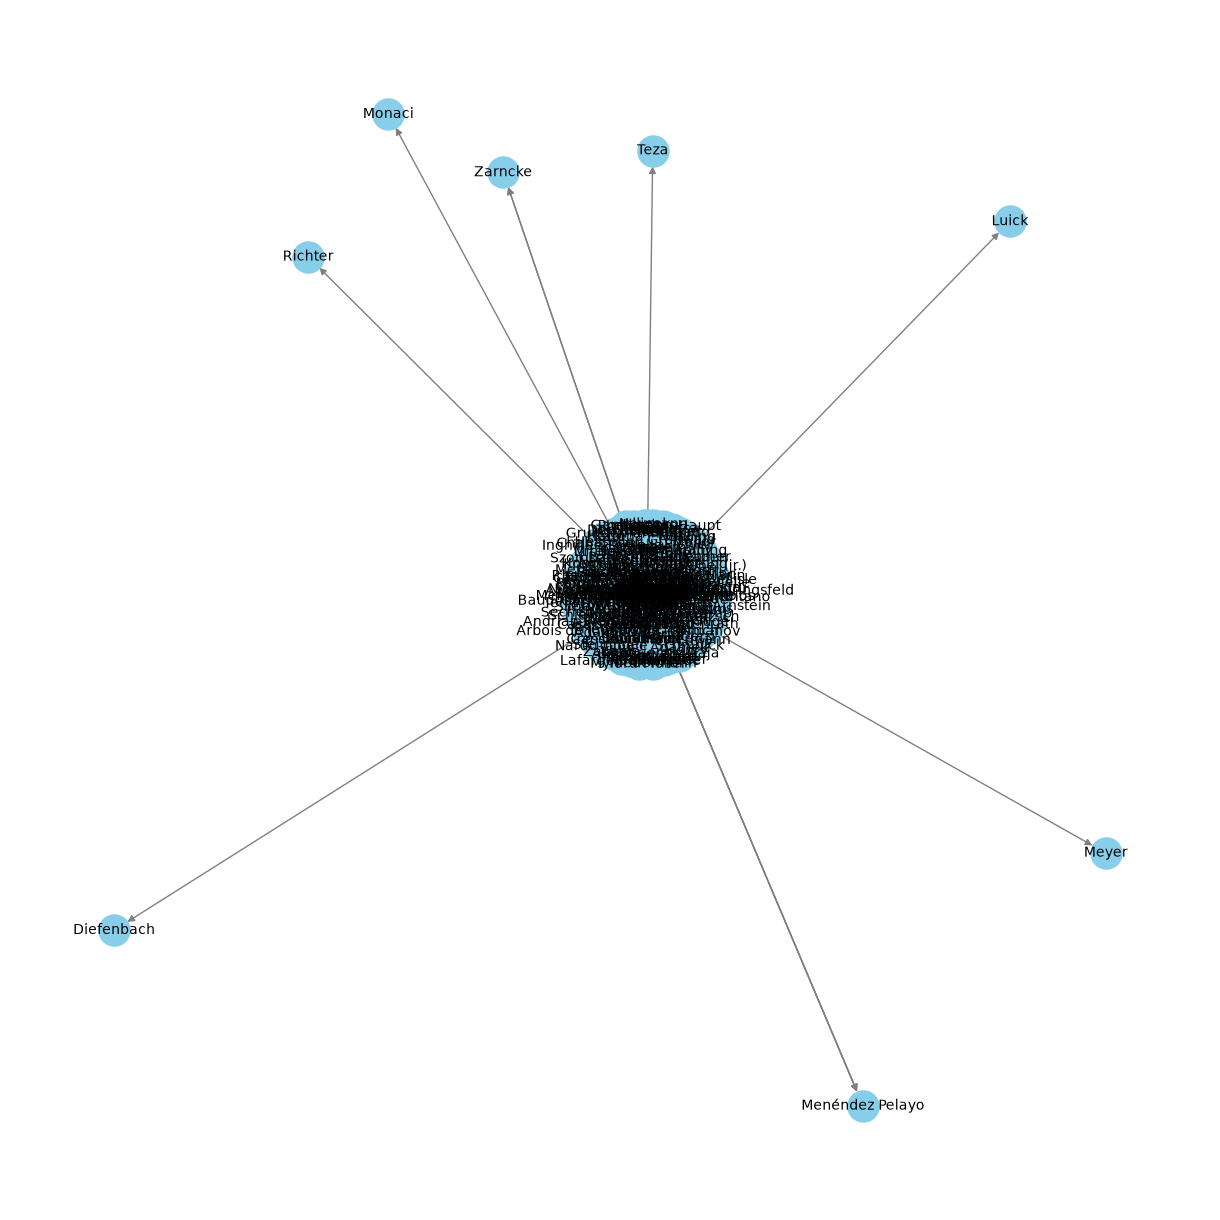

In [10]:
# visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    node_color="skyblue",
    font_size=10,
    font_color="black",
    edge_color="gray"
)
plt.show()

GraphML is an XML-based file format for graphs: it stores every node, every edge, and whatever attributes are attached to them, and it's readable by most network tools, including Gephi Lite. `edge_id_from_attribute="edge_id"` tells `networkx` to use the `edge_id` set on each edge as its identifier in the file, instead of generating its own, so the multiple edges between the same two people stay distinguishable once the file is opened.

In [ ]:
# save graphml file
nx.write_graphml(G, "sample_data/network.graphml", edge_id_from_attribute="edge_id")

## 2. A Person-to-Topic Network

The first graph only shows who wrote to whom directly. It can't show, for example, two people who never corresponded but wrote about the same thing. The second graph restructures the same rows around topics instead of around direct correspondence: every person and every topic becomes its own node, and each letter contributes two edges, sender to topic and receiver to topic, rather than one edge between two people. Two people who share a topic node end up connected through it, even without ever writing to each other. Every node also gets a `type` attribute, `person` or `topic`, so Gephi Lite can tell the two kinds apart later, for coloring or filtering; topic nodes are labeled with `gemma_label` rather than the numeric `topic_id`, so the exported graph reads in words instead of topic numbers.

In [12]:

G2 = nx.MultiDiGraph()
for row_index, (_, row) in enumerate(df.iterrows()):
    G2.add_node(row['sender'],
               label=row['sender'],
                type='person'
               )
    G2.add_node(row['receiver'],
               label=row['receiver'],
               type='person'
               )
    G2.add_node(row['topic_id'],
               label=row['gemma_label'],
               type='topic'
               )
    G2.add_edge(
        row['sender'],
        row['topic_id'],
        language=row['language'],
        edge_id=f"edge_{row_index}_sender"
    )
    G2.add_edge(
        row['receiver'],
        row['topic_id'],
        language=row['language'],
        edge_id=f"edge_{row_index}_receiver"
    )

A quick look at the nodes confirms both kinds ended up in the graph, people alongside topics.

In [13]:
G2.nodes

NodeView(('Geibel (jr.)', 'Schuchardt', 6, 'Erber', 0, 'Leite de Vasconcelos', -1, 'Sket', 'Jud', 'Friedwagner', 'Urquijo Ybarra', 14, 'Jarnik', 'Eichler', 'Suchier', 'Blumentritt', 5, 'Voretzsch', 'Gartner', 'Zwiedineck', 'Paris', 'Vries', 10, 'Ascoli', 12, 'Spitzer', 9, 'Windisch', 1, 'Bähr', 'Lacombe', 11, 'Simonyi', 'Müller', 'Zacher', 'Niemeyer', 26, 'Riegler', 'Gröber', 'Köhler', 'Priebsch', 2, 'Kaden', 'Lamp', 3, 'Pogatscher', 'Michaëlis de Vasconcelos', 'Pokorny', 'Mussafia', 'Pușcariu', 'Kern', 23, 4, 'Gatschet', 'Krenkel', 'Rutar', 27, 'Ettmayer', 7, 'Schmidt', 'Baudouin de Courtenay', 'Haberlandt', 'Šišmanov', 'Reinisch', 'Grundemann', 'Ive', 15, 'Lehmann-Haupt', 19, 'Hein', 'Reinsberg-Düringsfeld', 22, 'Kluge', 'D´Ancona', 25, 'Katona', 17, 'Gelzer', 'Morf', 'Meringer', 'Zarncke', 'Hesseling', 'Fischer', 'Vollmöller', 'Hoepffner', 'Leskien', 'Gauchat', 'Canstein', 'Lenz', 'Hestermann', 'Jespersen', 'Adamek', 'Erdmann', 20, 'Rhamm', 'Nobiling', 'D´Ovidio', 'Bettelheim', 'Grü

Same quick preview as before, now on the person-topic graph.

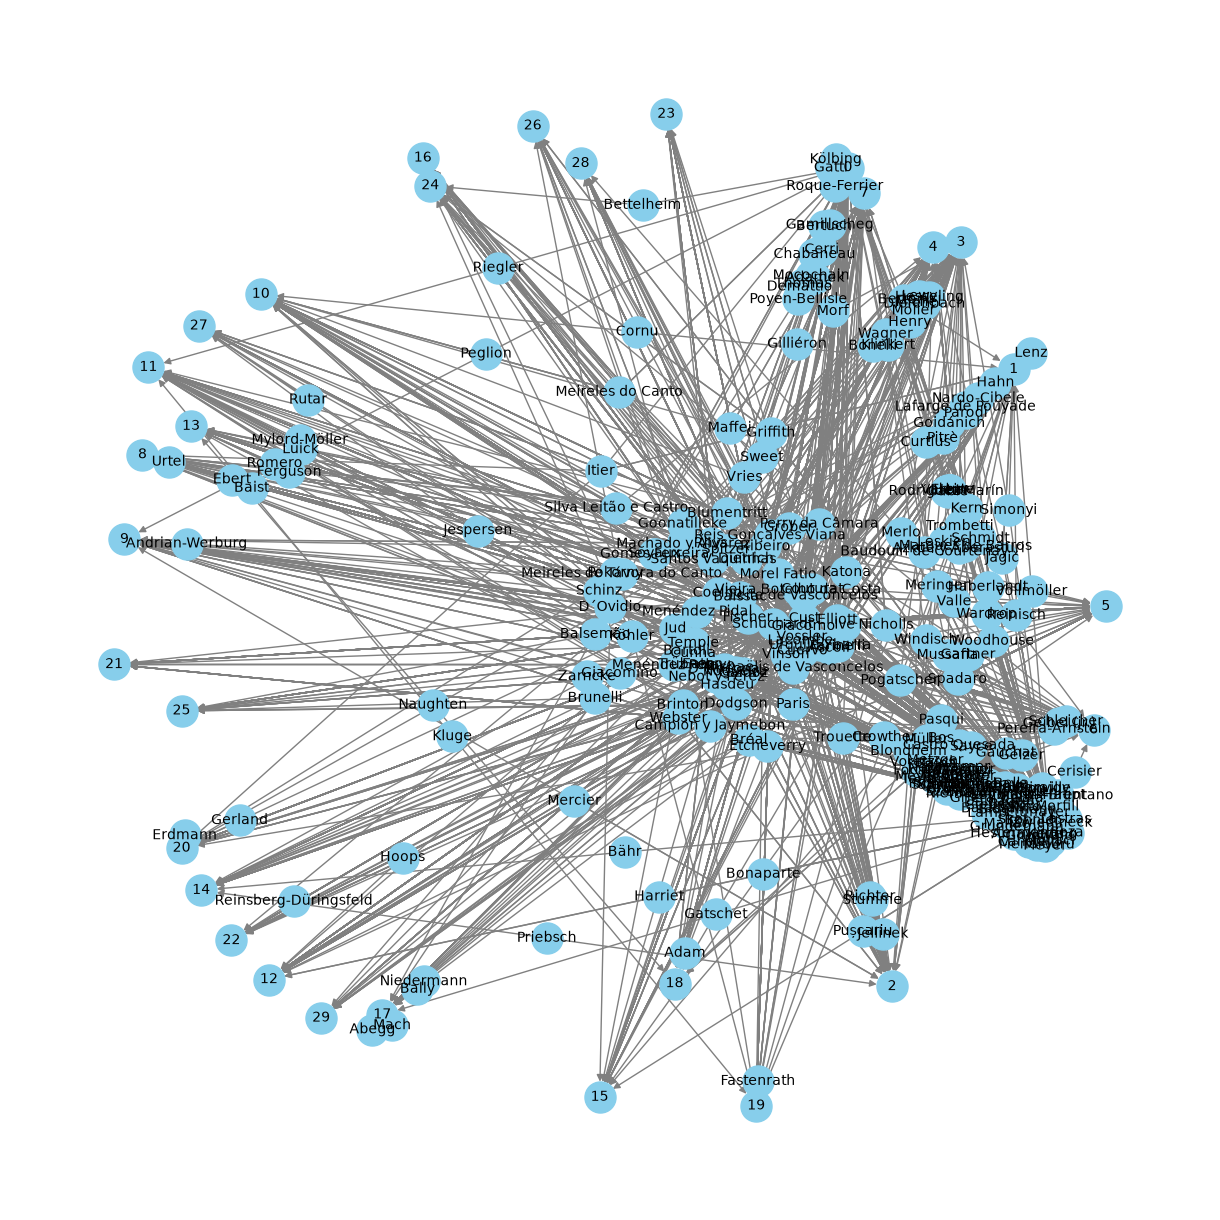

In [14]:
# visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G2)
nx.draw(
    G2,
    pos,
    with_labels=True,
    node_size=500,
    node_color="skyblue",
    font_size=10,
    font_color="black",
    edge_color="gray"
)
plt.show()

The same export step as before, this time for the person-topic graph.

In [15]:
# save graphml file
nx.write_graphml(G2, "sample_data/network_peopleandtopics.graphml", edge_id_from_attribute="edge_id")

Since every row contributes two edges here, sender to topic and receiver to topic, this count should come out to exactly twice the number of rows in `df`.

In [16]:
G2.number_of_edges()

3996